Importing the dependencies


In [35]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


Data collection and analysis


PIMA diabetes dataset


In [36]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset= pd.read_csv('/content/diabetes.csv')


In [37]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [38]:
# no of rows and coloumns in the dataset
diabetes_dataset.shape

(768, 9)

In [39]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [40]:
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [41]:
# ── EDA: Basic Overview ──
print("Shape:", diabetes_dataset.shape)
print("\nClass Distribution:")
print(diabetes_dataset['Outcome'].value_counts())

diabetes_dataset.describe()

Shape: (768, 9)

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


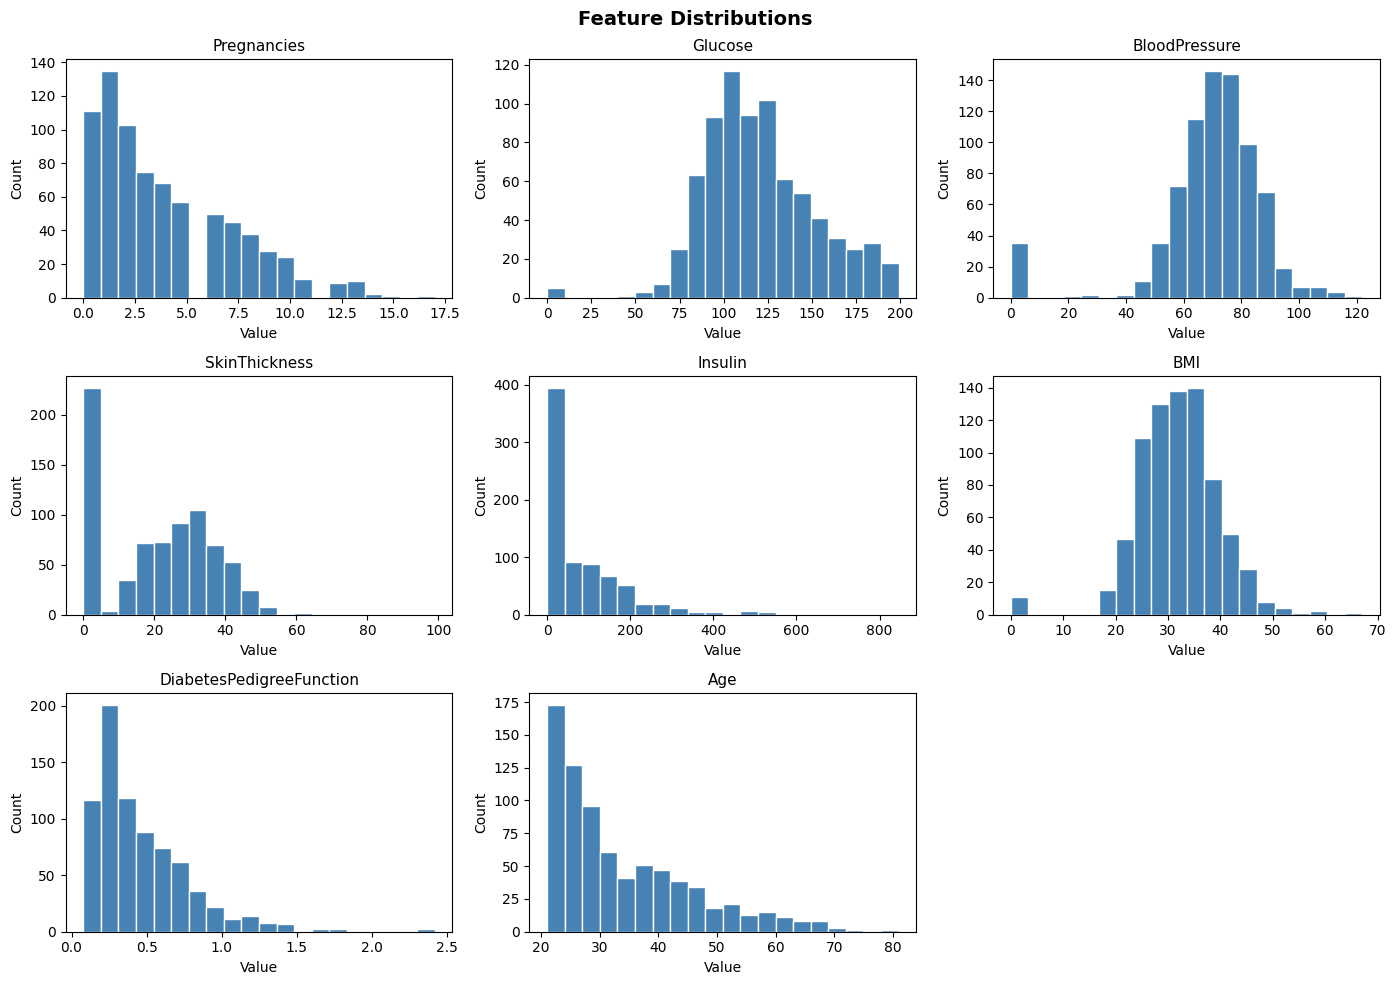

In [42]:
# ── EDA: Feature Histograms ──
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for i, col in enumerate(features):
    ax = axes[i // 3][i % 3]
    ax.hist(diabetes_dataset[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

axes[2][2].axis('off')  # hide empty 9th subplot
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

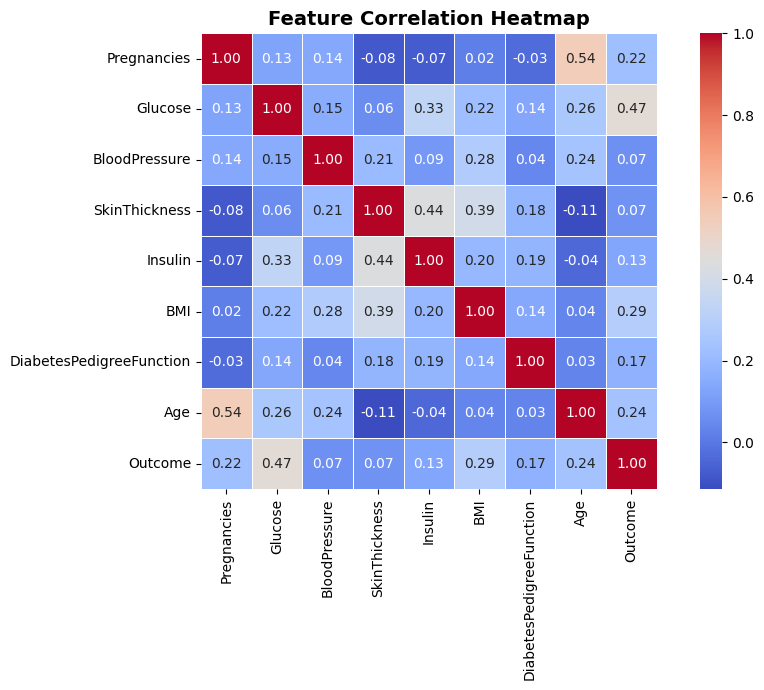

In [43]:
# ── EDA: Correlation Heatmap ──
plt.figure(figsize=(10, 7))
corr = diabetes_dataset.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

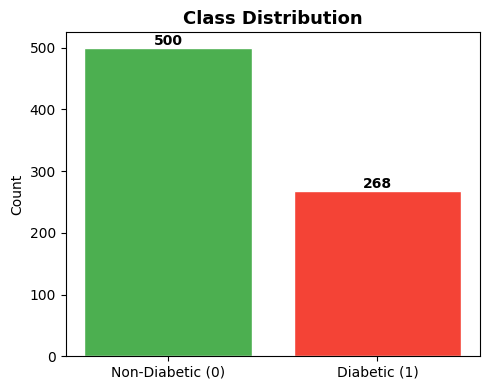

In [44]:
# ── EDA: Class Imbalance ──
counts = diabetes_dataset['Outcome'].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(['Non-Diabetic (0)', 'Diabetic (1)'], counts.values,
        color=['#4CAF50', '#F44336'], edgecolor='white')
plt.title('Class Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

0--> non- diabetic
1--> diabetic

In [45]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [46]:
# separating the data and labels
X= diabetes_dataset.drop(columns='Outcome', axis=1)
Y= diabetes_dataset['Outcome']

In [47]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [48]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Data standardisation

In [49]:
scaler= StandardScaler()


In [50]:
scaler.fit(X)

StandardScaler()

In [51]:
standardized_data= scaler.transform(X)

In [52]:
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [53]:
X= standardized_data
Y= diabetes_dataset['Outcome']

In [54]:
print(X)
print(Y)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Train test split

In [55]:
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [56]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


Training the model

In [57]:
classifier= svm.SVC(kernel='linear')

In [58]:
# training the support vector machine classifier
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

Model evaluation

Accuracy score

In [59]:
# accuracy score on the training data
X_train_prediction= classifier.predict(X_train)
training_data_accuracy= accuracy_score(X_train_prediction, Y_train)

In [60]:
print(' accuracy score of the training data:', training_data_accuracy)


 accuracy score of the training data: 0.7866449511400652


In [61]:
# accuracy score on the test data
X_test_prediction= classifier.predict(X_test)
test_data_accuracy= accuracy_score(X_test_prediction, Y_test)

In [62]:
print(' accuracy score of the testing data:', test_data_accuracy)

 accuracy score of the testing data: 0.7727272727272727


Making a predictive system

In [63]:
input_data= (4,110, 92, 0, 0, 37.6, 0.191, 30)
# changing the input data to numpy array
input_data_as_numpy_array= np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped= input_data_as_numpy_array.reshape(1, -1)

#standardize the input data
std_data= scaler.transform(input_data_reshaped)
print(std_data)

prediction= classifier.predict(std_data)
print(prediction)

if(prediction[0]==0):
  print('the person is not diabetic')
else:
   print('the person is diabetic')



[[ 0.04601433 -0.34096773  1.18359575 -1.28821221 -0.69289057  0.71168975
  -0.84827977 -0.27575966]]
[0]
the person is not diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [64]:
# ── Model Comparison ──
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=2),
    'SVM (Linear Kernel)': classifier  # your already-trained SVM
}

results = {}
for name, model in models.items():
    if name != 'SVM (Linear Kernel)':
        model.fit(X_train, Y_train)
    preds = model.predict(X_test)
    report = classification_report(Y_test, preds, output_dict=True)
    results[name] = {
        'Accuracy':  round(report['accuracy'] * 100, 2),
        'Precision': round(report['weighted avg']['precision'] * 100, 2),
        'Recall':    round(report['weighted avg']['recall'] * 100, 2),
        'F1-Score':  round(report['weighted avg']['f1-score'] * 100, 2),
    }
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(Y_test, preds))


  Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       100
           1       0.72      0.52      0.60        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.72       154
weighted avg       0.75      0.76      0.75       154


  Random Forest
              precision    recall  f1-score   support

           0       0.75      0.86      0.80       100
           1       0.65      0.48      0.55        54

    accuracy                           0.73       154
   macro avg       0.70      0.67      0.68       154
weighted avg       0.72      0.73      0.72       154


  SVM (Linear Kernel)
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       100
           1       0.76      0.52      0.62        54

    accuracy                           0.77       154
   macro avg       0.77      0.71      0.73       154
weighted av

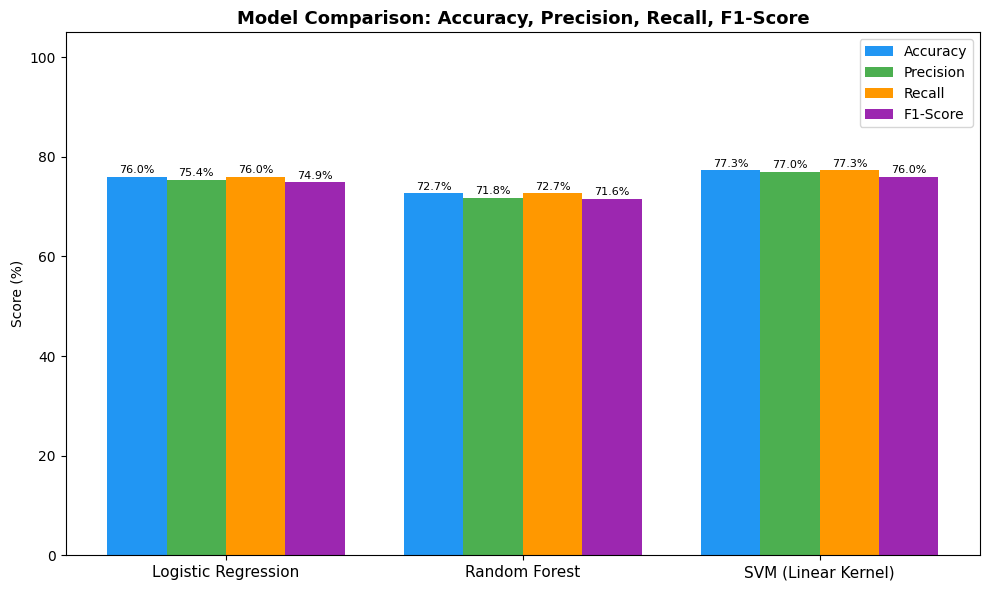

In [65]:
# ── Model Comparison Chart ──
import pandas as pd

results_df = pd.DataFrame(results).T
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = range(len(results_df))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(10, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar([p + i * width for p in x], results_df[metric],
                  width=width, label=metric, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks([p + 1.5 * width for p in x])
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison: Accuracy, Precision, Recall, F1-Score',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

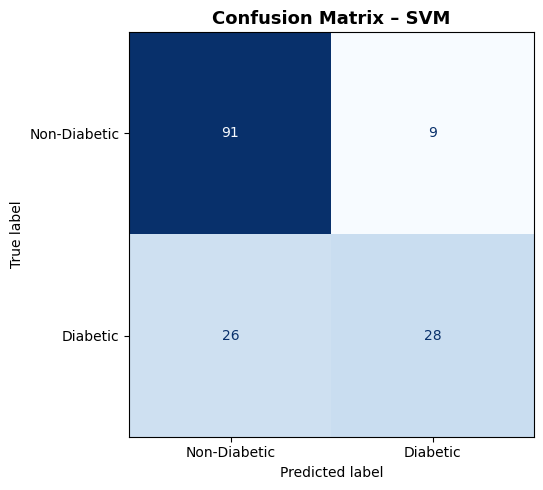

In [66]:
# ── Confusion Matrix: SVM ──
Y_pred_svm = classifier.predict(X_test)
cm = confusion_matrix(Y_test, Y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Diabetic', 'Diabetic'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – SVM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

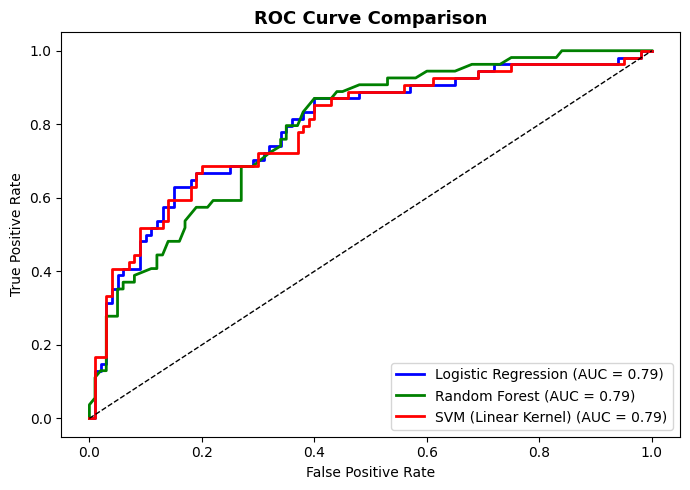

In [67]:
# ── ROC Curve ──
fig, ax = plt.subplots(figsize=(7, 5))
model_colors = {'Logistic Regression': 'blue',
                'Random Forest': 'green',
                'SVM (Linear Kernel)': 'red'}

for name, model in models.items():
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
    else:
        scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})',
            color=model_colors[name], lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()